In [1]:
%cd ..
import nibabel as nib
from  deepmrac.utils import sort_files, convert_to_nifti, load_and_resample_images, resample_to_output_format, to_dcm
from deepmrac.predictions import predict_DeepT1
from deepmrac.metrics import calculate_quality_metrics, save_metrics_to_csv
import numpy as np

/Users/anne-gabrielle/Le_Neuro/DeepMRAC


In [2]:
import pydicom
import os

def check_series(folder):
    all_files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    nb_files = len(all_files)
    
    if nb_files == 0:
        print(f"The folder {folder} is empty.")
        return

    first_file = all_files[0]
    ds = pydicom.dcmread(os.path.join(folder, first_file))
    
    print(f"Folder: {folder}")
    print(f"  - Description: {ds.SeriesDescription}")
    print(f"  - Modality:    {ds.Modality}")
    print(f"  - Matrice:     {ds.Rows}x{ds.Columns}")
    print(f"  - Files number: {nb_files}")
    print("-" * 30)

check_series('./datasets/T1/MPRAGE_0007')
check_series('./datasets/T1/HEAD_MRAC_BRAIN_HIRES_IN_UMAP_0006')

Folder: ./datasets/T1/MPRAGE_0007
  - Description: MPRAGE
  - Modality:    MR
  - Matrice:     640x640
  - Files number: 209
------------------------------
Folder: ./datasets/T1/HEAD_MRAC_BRAIN_HIRES_IN_UMAP_0006
  - Description: Head_MRAC_Brain_HiRes_in_UMAP
  - Modality:    MR
  - Matrice:     126x240
  - Files number: 132
------------------------------


# T1

In [15]:
tmpdir="./temp_file"
t1_path="./datasets/T1/MPRAGE_0007"
umap_path="./datasets/T1/HEAD_MRAC_BRAIN_HIRES_IN_UMAP_0006"
verbose=True
version='VE11P'
output_folder=f"./output/T1/{version}"

In [16]:
sort_files(source_folder=t1_path, temp_subfolder=f"{tmpdir}/t1_dcm", verbose=verbose)
convert_to_nifti(dicom_dir=f"{tmpdir}/t1_dcm", output_nii=f"{tmpdir}/t1.nii.gz", verbose=verbose)

sort_files(source_folder=umap_path, temp_subfolder=f"{tmpdir}/umap_dcm", verbose=verbose)
convert_to_nifti(dicom_dir=f"{tmpdir}/umap_dcm", output_nii=f"{tmpdir}/umap.nii.gz", verbose=verbose)

Found files in ./datasets/T1/MPRAGE_0007. Making copy
Converting ./temp_file/t1_dcm to ./temp_file/t1.nii.gz
Found files in ./datasets/T1/HEAD_MRAC_BRAIN_HIRES_IN_UMAP_0006. Making copy
Converting ./temp_file/umap_dcm to ./temp_file/umap.nii.gz


In [17]:
t1_rsl, t1_ref = load_and_resample_images(nii_image=f"{tmpdir}/t1.nii.gz", verbose=verbose)
umap_nat = nib.load(f'{tmpdir}/umap.nii.gz')

Loading and resampling data from ./temp_file/t1.nii.gz.


In [18]:
# Flip to match orientation on what was trained on
t1_rsl = np.flipud(np.swapaxes(t1_rsl, 0, 2)) 

In [19]:
pred = predict_DeepT1(t1=t1_rsl, version=version)
pred = np.swapaxes(np.flipud(pred), 2, 0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [20]:
# Resample: T1 Resolution and Umap Format
DeepX = resample_to_output_format(pred=pred, model_ref=t1_ref, umap_native=umap_nat, rmi_type="T1", verbose=verbose, save_prediction=True)

Resampling to Umap format
Saving QC nii file to DeepT1_QC.nii.gz


In [21]:
# Final DICOM (using Umap as container)
DeepX = np.transpose(DeepX, (1, 2, 0))
DeepX = np.flip(DeepX, axis=0)
DeepX = np.flip(DeepX, axis=1)
to_dcm(DeepX=DeepX, dcmcontainer=f"{tmpdir}/umap_dcm", dicomfolder=output_folder, rmi_type="T1")

In [22]:
# Calculate metrics
metrics_dict = calculate_quality_metrics(
            sct_path=output_folder,
            umap_path=f"{tmpdir}/umap_dcm",
        )


if verbose:
    print("\n" + "="*30)
    print(" GLOBAL QUALITY METRICS ")
    print("="*30)
    print(f"PSNR: {metrics_dict['PSNR']:.2f}")
    print(f"SSIM: {metrics_dict['SSIM']:.4f}")
            
    for mode in ['tissue', 'bone']:
        print(f"\n--- {mode.upper()} ANALYSIS ---")
        print(f"MAE:  {metrics_dict[f'{mode}_MAE']:.4f}")
        print(f"ME:   {metrics_dict[f'{mode}_ME']:.4f}")
        print(f"RE:   {metrics_dict[f'{mode}_RE']:.4f}")
        print(f"ARE:  {metrics_dict[f'{mode}_ARE']:.4f}")
        print(f"Dice: {metrics_dict[f'{mode}_Dice']:.4f}")
    print("="*30)



 GLOBAL QUALITY METRICS 
PSNR: 26.05
SSIM: 0.9301

--- TISSUE ANALYSIS ---
MAE:  23.9463
ME:   -8.5061
RE:   0.6467
ARE:  0.6889
Dice: 1.0000

--- BONE ANALYSIS ---
MAE:  196.7918
ME:   -91.0713
RE:   -0.0960
ARE:  0.2176
Dice: 0.9308


In [23]:
save_metrics_to_csv(metrics_dict=metrics_dict, rmi_type='T1', output_folder=f"{output_folder}/metrics")

Metrics saved at : ./output/T1/VE11P/metrics/all_metrics.csv


# Visualisation

In [27]:
import matplotlib.pyplot as plt
import pydicom
import os

def plot_dicom_file(file):
    ds = pydicom.dcmread(file)

    data = ds.pixel_array
    print(f"Max value: {data.max()}")
    print(f"Min value: {data.min()}")
    print(f"Mean value: {data.mean()}")
    print(f"Dimensions : {ds.Rows}x{ds.Columns}")
    
    plt.imshow(data, cmap='gray')
    plt.title(f"Slice {ds.InstanceNumber} - {ds.SeriesDescription}")
    plt.show()

def scan_folder_for_data(folder):
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.ima', '.dcm'))])
    print(f"{len(files)} files found...")
    
    valid_files_count = 0
    
    for f in files:
        try:
            ds = pydicom.dcmread(f)
            pixel_max = ds.pixel_array.max()
            
            if pixel_max > 0:
                print(f"✅ {os.path.basename(f)} | Max : {pixel_max}")
                valid_files_count += 1
                
        except Exception as e:
            print(f"An error occured when trying to read {os.path.basename(f)} : {e}")
            
    print("-" * 30)
    if valid_files_count > 0:
        print(f"Result : {valid_files_count}/{len(files)} files have data.")
    else:
        print("Results : No data found in anu of the files.")

## Deep learning outcom

In [25]:
scan_folder_for_data("./output/T1/VE11P")

132 files found...
✅ dicom_0004.dcm | Max : 1
✅ dicom_0016.dcm | Max : 1
✅ dicom_0019.dcm | Max : 1
✅ dicom_0020.dcm | Max : 170
✅ dicom_0021.dcm | Max : 906
✅ dicom_0022.dcm | Max : 968
✅ dicom_0023.dcm | Max : 1451
✅ dicom_0024.dcm | Max : 1754
✅ dicom_0025.dcm | Max : 1728
✅ dicom_0026.dcm | Max : 1698
✅ dicom_0027.dcm | Max : 1680
✅ dicom_0028.dcm | Max : 1694
✅ dicom_0029.dcm | Max : 1672
✅ dicom_0030.dcm | Max : 1659
✅ dicom_0031.dcm | Max : 1710
✅ dicom_0032.dcm | Max : 1696
✅ dicom_0033.dcm | Max : 1706
✅ dicom_0034.dcm | Max : 1730
✅ dicom_0035.dcm | Max : 1891
✅ dicom_0036.dcm | Max : 1945
✅ dicom_0037.dcm | Max : 2223
✅ dicom_0038.dcm | Max : 2462
✅ dicom_0039.dcm | Max : 2406
✅ dicom_0040.dcm | Max : 2424
✅ dicom_0041.dcm | Max : 2471
✅ dicom_0042.dcm | Max : 2448
✅ dicom_0043.dcm | Max : 2463
✅ dicom_0044.dcm | Max : 2478
✅ dicom_0045.dcm | Max : 2488
✅ dicom_0046.dcm | Max : 2474
✅ dicom_0047.dcm | Max : 2442
✅ dicom_0048.dcm | Max : 2385
✅ dicom_0049.dcm | Max : 2246
✅ d

Max value: 2462
Min value: 0
Mean value: 122.73422619047619
Dimensions : 126x240


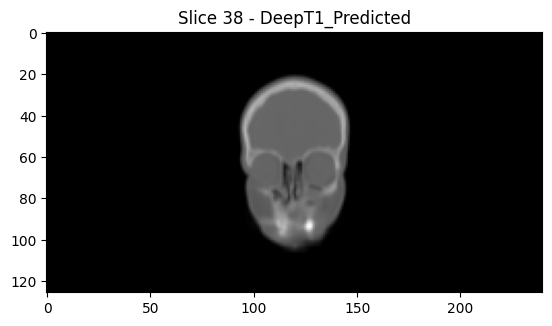

In [28]:
plot_dicom_file("./output/T1/VE11P/dicom_0038.dcm")

In [15]:
scan_folder_for_data("./output/T1/VB20P")

132 files found...
✅ dicom_0008.dcm | Max : 1
✅ dicom_0009.dcm | Max : 1
✅ dicom_0010.dcm | Max : 2
✅ dicom_0011.dcm | Max : 2
✅ dicom_0012.dcm | Max : 3
✅ dicom_0013.dcm | Max : 3
✅ dicom_0014.dcm | Max : 3
✅ dicom_0015.dcm | Max : 3
✅ dicom_0016.dcm | Max : 3
✅ dicom_0017.dcm | Max : 4
✅ dicom_0018.dcm | Max : 7
✅ dicom_0019.dcm | Max : 38
✅ dicom_0020.dcm | Max : 542
✅ dicom_0021.dcm | Max : 909
✅ dicom_0022.dcm | Max : 1284
✅ dicom_0023.dcm | Max : 1643
✅ dicom_0024.dcm | Max : 1757
✅ dicom_0025.dcm | Max : 1743
✅ dicom_0026.dcm | Max : 1731
✅ dicom_0027.dcm | Max : 1749
✅ dicom_0028.dcm | Max : 1745
✅ dicom_0029.dcm | Max : 1731
✅ dicom_0030.dcm | Max : 1719
✅ dicom_0031.dcm | Max : 1767
✅ dicom_0032.dcm | Max : 1780
✅ dicom_0033.dcm | Max : 1727
✅ dicom_0034.dcm | Max : 1726
✅ dicom_0035.dcm | Max : 1771
✅ dicom_0036.dcm | Max : 1705
✅ dicom_0037.dcm | Max : 1774
✅ dicom_0038.dcm | Max : 1703
✅ dicom_0039.dcm | Max : 1824
✅ dicom_0040.dcm | Max : 2097
✅ dicom_0041.dcm | Max : 233

Max value: 1703
Min value: 0
Mean value: 126.1525462962963
Dimensions : 126x240


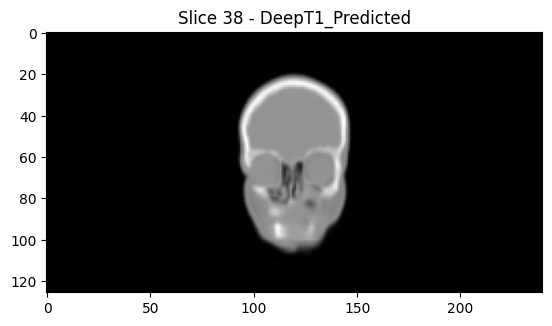

In [16]:
plot_dicom_file("./output/T1/VB20P/dicom_0038.dcm")

## Original Umaps

In [17]:
scan_folder_for_data("./datasets/T1/HEAD_MRAC_BRAIN_HIRES_IN_UMAP_0006")

132 files found...
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0019.2024.03.20.10.09.08.525089.21258766.IMA | Max : 16
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0020.2024.03.20.10.09.08.525089.21258784.IMA | Max : 966
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0021.2024.03.20.10.09.08.525089.21258802.IMA | Max : 1000
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0022.2024.03.20.10.09.08.525089.21258820.IMA | Max : 1138
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0023.2024.03.20.10.09.08.525089.21258838.IMA | Max : 1564
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0024.2024.03.20.10.09.08.525089.21258856.IMA | Max : 1584
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0025.2024.03.20.10.09.08.525089.21258874.IMA | Max : 1546
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0026.2024.03.20.10.09.08.525089.21258892.IMA | Max : 1578
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0027.2024.03.20.10.09.08.525089.21258910.IMA | Max : 1555
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0028.2024.03.20.10.09.08.525089.21258928.IMA | Max : 1608
✅ REMIND_22.MR.BRAIN_ANAZODO.0006.0029.2024.03.20.10.09.08.52508

Max value: 2131
Min value: 0
Mean value: 125.50939153439154
Dimensions : 126x240


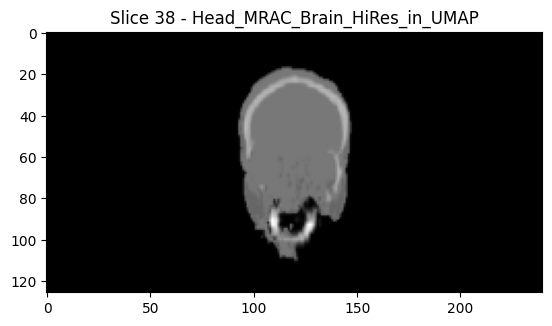

In [18]:
plot_dicom_file("./datasets/T1/HEAD_MRAC_BRAIN_HIRES_IN_UMAP_0006/REMIND_22.MR.BRAIN_ANAZODO.0006.0038.2024.03.20.10.09.08.525089.21259108.IMA")

## T1 dicoms

Max value: 704
Min value: 0
Mean value: 116.63275390625
Dimensions : 640x640


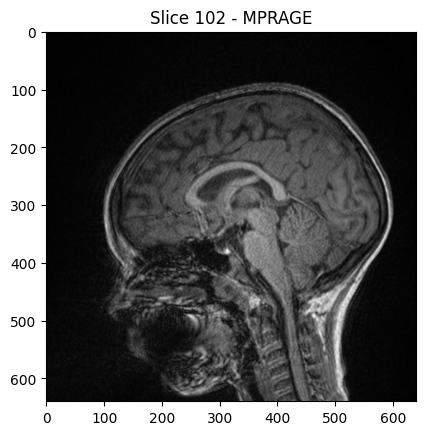

In [19]:
plot_dicom_file("./datasets/T1/MPRAGE_0007/REMIND_22.MR.BRAIN_ANAZODO.0007.0102.2024.03.20.10.09.08.525089.21264365.IMA")